In [1]:
# pip install seaborn

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: seaborn in c:\users\yhara\appdata\local\packages\pythonsoftwarefoundation.python.3.11_qbz5n2kfra8p0\localcache\local-packages\python311\site-packages (0.13.0)




[notice] A new release of pip is available: 23.2.1 -> 23.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
from utils import DQN, ReplayBuffer, greedy_action, epsilon_greedy, update_target, loss

import torch # ML library 
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
import math
import numpy as np

import gym # provides various RL environments
import matplotlib.pyplot as plt

import os
import fnmatch
import logging 
import seaborn as sns

In [3]:
# Parameters 
NUM_RUNS = 3
EPSILON = 0.1     # placeholder value - you should implement your own exploration schedule
lr = 0.01
num_episodes = 300
batch_size = 32
buffer_size = 100000
update_period = 15
decay_rate = 0.995
initial_epsilon = 1
min_epsilon = 0.1

In [6]:

env = gym.make('CartPole-v1')

# Assuming runs_results is defined
runs_results = []

# Define the parameters
batch_sizes = [16, 32, 64, 128]  # Adjust these values as needed
buffer_sizes = [100, 1000, 10000, 100000]  # Adjust these values as needed

# Create a matrix to store the mean episode durations for different configurations
mean_durations = np.zeros((len(buffer_sizes), len(batch_sizes)))

for i, buffer_size in enumerate(buffer_sizes):
    for j, batch_size in enumerate(batch_sizes):
        # Assuming runs_results contains lists of episode durations
        # Calculate mean of the episode durations for each configuration of buffer_size and batch_size
        for run in range(NUM_RUNS):
            print(f"Starting run {run+1} of {NUM_RUNS}")

            architecture = [4, 50, 50, 2]
            policy_net = DQN(architecture) # input = 4 and output = 2 (0 or 1) 
            target_net = DQN(architecture)
            update_target(target_net, policy_net)
            target_net.eval()
            
            # Layer size
            layer_size = architecture[1]

            optimizer = optim.SGD(policy_net.parameters(), lr) # stochastic gradient descent, learning rate
            # optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
            memory = ReplayBuffer(buffer_size) # 1 originally 

            steps_done = 0

            episode_durations = []

            EPSILON = initial_epsilon

            for i_episode in range(num_episodes): # can adjust num_episodes 
                if (i_episode+1) % 50 == 0:
                    print("episode ", i_episode+1, "/", 300)

                observation, info = env.reset()
                state = torch.tensor(observation).float()

                done = False
                terminated = False
                t = 0
                EPSILON = max(1/(i_episode+1), min_epsilon)
                while not (done or terminated):

                    # Select and perform an action
                    action = epsilon_greedy(EPSILON, policy_net, state)
                    # action = greedy_action(policy_net, state) # can try without epsilon greedy 

                    # reward is a scalar, [reward] creates a one-element list, which is converted into a tensor
                    observation, reward, done, terminated, info = env.step(action)
                    reward = torch.tensor([reward])
                    action = torch.tensor([action])
                    next_state = torch.tensor(observation).reshape(-1).float()

                    # store in replay buffer
                    memory.push([state, action, next_state, reward, torch.tensor([done])])

                    # Move to the next state
                    state = next_state

                    # Perform one step of the optimization (on the policy network)
                    if not len(memory.buffer) < batch_size: # only proceed if enough data in buffer 
                        transitions = memory.sample(batch_size) # sample one transition from buffer
                        state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions)) # and unpack
                        # Compute loss
                        mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                        # Optimize the model
                        optimizer.zero_grad() # from optimizer, reset gradient to prep for new step 
                        mse_loss.backward() # store gradient of the loss wrt each para 
                        optimizer.step() # carry out gradient dedscent step & update of para 
                    
                    if done or terminated:
                        episode_durations.append(t + 1)
                    t += 1
                # Update the target network, copying all weights and biases in DQN
                if i_episode % update_period == 0: 
                    update_target(target_net, policy_net)
            runs_results.append(episode_durations)
        print('Complete')

        mean_duration = np.mean([np.mean(run[200:300]) for run in runs_results])
        # mean_duration = np.std([np.mean(run[200:300]) for run in runs_results])
        mean_durations[i][j] = mean_duration


Starting run 1 of 3


C:\Users\yhara\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete
Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete
Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 /

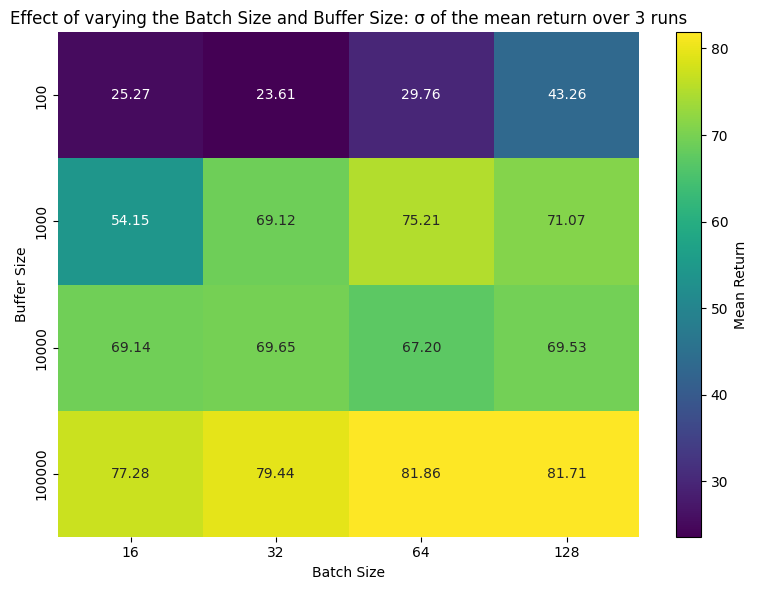

In [7]:
# Create subplots
fig, ax = plt.subplots(figsize=(8, 6))

# Create a heatmap using Seaborn on Matplotlib
sns.heatmap(mean_durations, annot=True, fmt=".2f", cmap='viridis', xticklabels=batch_sizes, yticklabels=buffer_sizes, ax=ax)

# Setting labels, ticks, and title
ax.set_title('Effect of varying the Batch Size and Buffer Size: mean return over 3 runs') #CHANGE STD 
ax.set_xlabel('Batch Size')
ax.set_ylabel('Buffer Size')

# Get the current Axes instance on the current figure
cax = plt.gcf().axes[-1]

# Create a colorbar for the entire figure
cbar = plt.colorbar(ax.collections[0], cax=cax)
cbar.set_label('Mean Return')

plt.tight_layout()
plt.show()

In [8]:
plt.savefig("C:/Users/yhara/OneDrive - Imperial College London/YEAR 4/RL/Heatmap batch buffer.svg")

<Figure size 640x480 with 0 Axes>

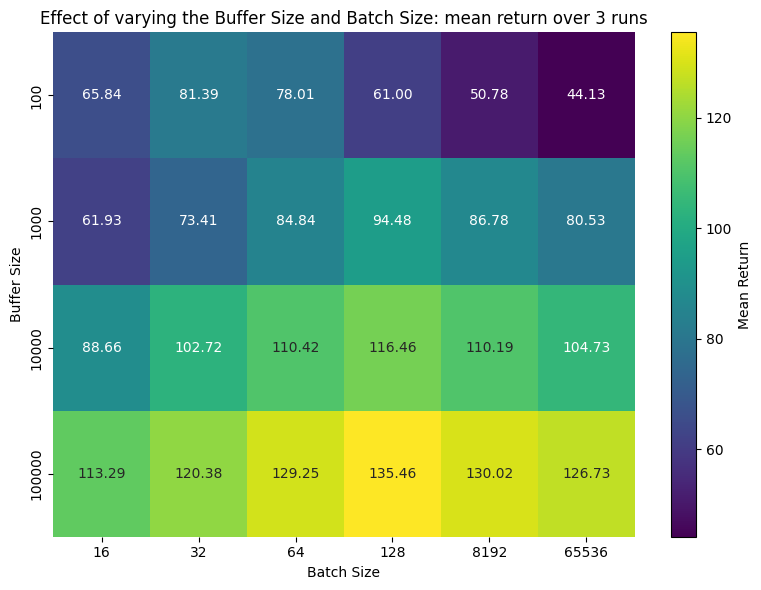

In [7]:
# import numpy as np

data = np.load('heatmapBufferBatch1.npy')

batch_sizes = [16, 32, 64, 128, 8192, 65536]  # Adjust these values as needed
buffer_sizes = [100, 1000, 10000, 100000]  # Adjust these values as needed
# Create subplots
fig, ax = plt.subplots(figsize=(8, 6))

# Create a heatmap using Seaborn on Matplotlib
sns.heatmap(data, annot=True, fmt=".2f", cmap='viridis', xticklabels=batch_sizes, yticklabels=buffer_sizes, ax=ax)

# Setting labels, ticks, and title
ax.set_title('Effect of varying the Buffer Size and Batch Size: mean return over 3 runs') #CHANGE STD 
ax.set_xlabel('Batch Size')
ax.set_ylabel('Buffer Size')

# Get the current Axes instance on the current figure
cax = plt.gcf().axes[-1]

# Create a colorbar for the entire figure
cbar = plt.colorbar(ax.collections[0], cax=cax)
cbar.set_label('Mean Return')

plt.tight_layout()
plt.show()